In [1]:
experiment_name = "COVID_A_200iter"

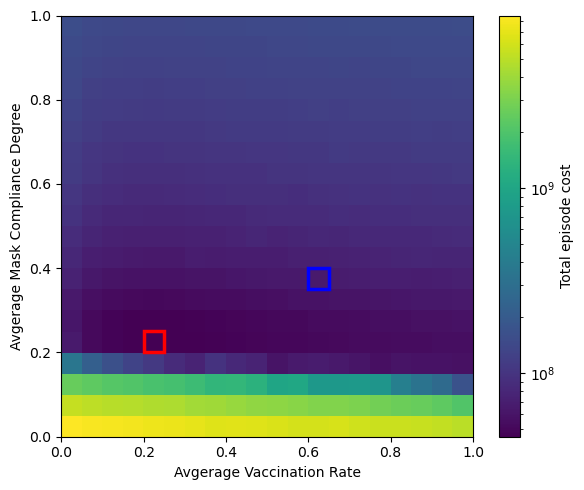

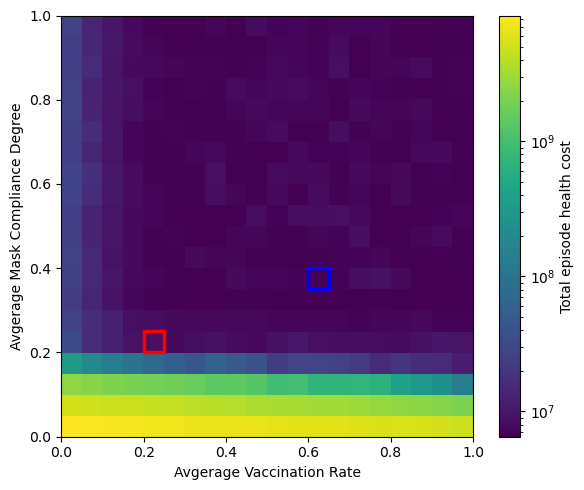

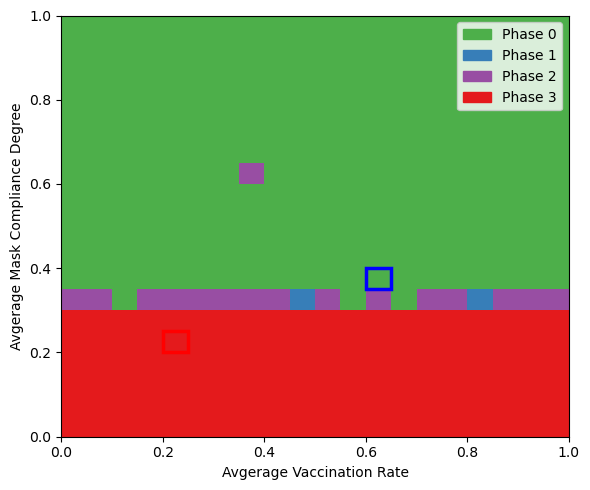

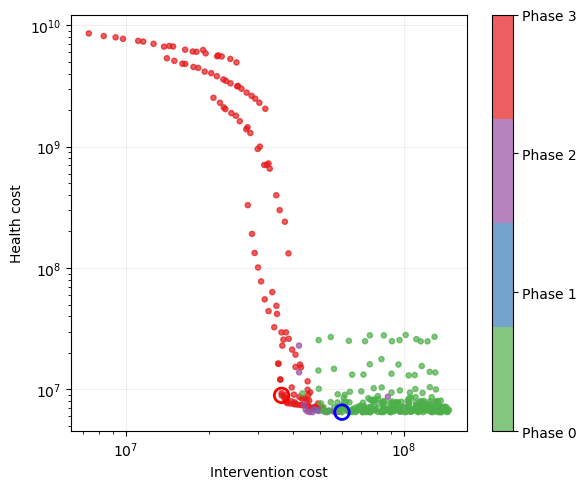

In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from matplotlib.colors import SymLogNorm
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatterMathtext

# Load archive CSV
folder_path = r"C:\Users\mrdxy\Documents\MLDS\Final Project\Notebooks\saved_archives"
csv_path = f"{folder_path}\\{experiment_name}_archive_corrected.csv"
archive_df = pd.read_csv(csv_path)

img_folder = r"C:\Users\mrdxy\Documents\MLDS\Final Project\saved_figs"
img_folder = f"{img_folder}\\{experiment_name}"
if not os.path.exists(img_folder):
    os.makedirs(img_folder)

colors = plt.get_cmap("Set1").colors
color_list = [colors[2], colors[1], colors[3], colors[0]]

# Extract fields
measures = archive_df[["measures_0", "measures_1"]].to_numpy()
objectives = archive_df["objective"].to_numpy()
indices = archive_df["index"].to_numpy().astype(int)
phases = archive_df["phase"].to_numpy()
health_cost = archive_df["health_cost"].to_numpy()
inter_cost = archive_df["inter_cost"].to_numpy()

feature_name_1 = "Avgerage Mask Compliance Degree"
feature_name_2 = "Avgerage Vaccination Rate"

# Archive data
archive_range_1 = (0.0, 1.0)
archive_range_2 = (0.0, 1.0)
dims = (20, 20)

# Best cell
best_row_idx = (archive_df["health_cost"]+archive_df["inter_cost"]).idxmin()
best_row = archive_df.loc[best_row_idx]
best_bin = int(best_row["index"])
best_measures = best_row[["measures_0", "measures_1"]].to_numpy(dtype=float)
best_obj = float(best_row["objective"])
best_phase = int(best_row["phase"])
best_health = float(best_row["health_cost"])
best_inter = float(best_row["inter_cost"])
best_i, best_j = np.unravel_index(best_bin, dims)

# Best health cell
besthealth_row_idx = archive_df["health_cost"].idxmin()
besthealth_row = archive_df.loc[besthealth_row_idx]
besthealth_bin = int(besthealth_row["index"])
besthealth_measures = besthealth_row[["measures_0", "measures_1"]].to_numpy(dtype=float)
besthealth_obj = float(besthealth_row["objective"])
besthealth_phase = int(besthealth_row["phase"])
besthealth_health = float(besthealth_row["health_cost"])
besthealth_inter = float(besthealth_row["inter_cost"])
besthealth_i, besthealth_j = np.unravel_index(besthealth_bin, dims)

# Cell sizes for heatmaps
cell_w = (archive_range_2[1] - archive_range_2[0]) / dims[1]
cell_h = (archive_range_1[1] - archive_range_1[0]) / dims[0]

# Lower-left corner of the best heatmap cell
best_cell_x = archive_range_2[0] + best_j * cell_w
best_cell_y = archive_range_1[0] + best_i * cell_h

besthealth_cell_x = archive_range_2[0] + besthealth_j * cell_w
besthealth_cell_y = archive_range_1[0] + besthealth_i * cell_h


def add_best_cell_border(ax, x, y, w, h, color="red", lw=2.5):
    rect = Rectangle((x, y), w, h, fill=False, edgecolor=color, linewidth=lw, zorder=20)
    ax.add_patch(rect)


def add_best_dot_border(ax, x, y, s=70, color="red", lw=2.0):
    ax.scatter([x], [y], s=s, facecolors="none", edgecolors=color, linewidths=lw, zorder=20)


def plot_reward_heatmap(archive_range_1, archive_range_2, dims, objectives, indices,
                        feature_name_1, feature_name_2,
                        best_cell_x=None, best_cell_y=None, cell_w=None, cell_h=None,
                        besthealth_cell_x=None, besthealth_cell_y=None, savename=None,
                        only_health=False):
    left, right = archive_range_2
    bottom, top = archive_range_1

    reward_grid = np.full(dims, np.nan, dtype=float)

    for value, idx in zip(objectives, indices):
        i, j = np.unravel_index(int(idx), dims)
        reward_grid[i, j] = value

    norm = LogNorm(
        vmin=reward_grid.min(),
        vmax=reward_grid.max()
    )
    
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(
        reward_grid,
        origin="lower",
        cmap="viridis",
        aspect="auto",
        interpolation="nearest",
        extent=(left, right, bottom, top),
        norm=norm
    )
    if only_health:
        fig.colorbar(im, ax=ax, label="Total episode health cost")
    else:
        fig.colorbar(im, ax=ax, label="Total episode cost")
    
    ax.set_xlabel(feature_name_2)
    ax.set_ylabel(feature_name_1)

    if best_cell_x is not None:
        add_best_cell_border(ax, best_cell_x, best_cell_y, cell_w, cell_h)

    if besthealth_cell_x is not None:
        add_best_cell_border(ax, besthealth_cell_x, besthealth_cell_y, cell_w, cell_h, color="blue")

    plt.tight_layout()
    if savename != None:
        plt.savefig(savename)
    plt.show()


def plot_phase_diagram(archive_range_1, archive_range_2, dims, phases, indices,
                       feature_name_1, feature_name_2,
                       best_cell_x=None, best_cell_y=None, cell_w=None, cell_h=None,
                       besthealth_cell_x=None, besthealth_cell_y=None, savename=None):
    left, right = archive_range_2
    bottom, top = archive_range_1

    phase_grid = np.full(dims, np.nan, dtype=float)

    for phase, idx in zip(phases, indices):
        i, j = np.unravel_index(int(idx), dims)
        phase_grid[i, j] = phase

    cmap = ListedColormap(color_list)

    fig, ax = plt.subplots(figsize=(6, 5))
    im2 = ax.imshow(
        phase_grid,
        origin="lower",
        cmap=cmap,
        vmin=0,
        vmax=3,
        aspect="auto",
        interpolation="nearest",
        extent=(left, right, bottom, top),
    )
    ax.set_xlabel(feature_name_2)
    ax.set_ylabel(feature_name_1)

    labels = ["Phase 0", "Phase 1", "Phase 2", "Phase 3"]
    handles = [mpatches.Patch(color=cmap(i), label=labels[i]) for i in range(4)]
    ax.legend(handles=handles, loc="upper right", frameon=True)

    if best_cell_x is not None:
        add_best_cell_border(ax, best_cell_x, best_cell_y, cell_w, cell_h)

    if besthealth_cell_x is not None:
        add_best_cell_border(ax, besthealth_cell_x, besthealth_cell_y, cell_w, cell_h, color="blue")

    plt.tight_layout()
    if savename != None:
        plt.savefig(savename)
    plt.show()


def plot_phase_pareto(inter_cost, health_cost, phase, best_inter=None, best_health=None,
                      besthealth_inter=None, besthealth_health=None, savename=None):
    cmap = ListedColormap(color_list)

    fig, ax = plt.subplots(figsize=(6, 5))
    sc = ax.scatter(inter_cost, health_cost, c=phase, cmap=cmap, s=14, alpha=0.7)
    ax.set_xlabel("Intervention cost")
    ax.set_ylabel("Health cost")
    #ax.set_title("Health vs intervention cost, colored by phase")
    ax.set_xscale("log")
    ax.set_yscale("log")
    cbar = fig.colorbar(sc, ax=ax, ticks=[0, 1, 2, 3])
    cbar.ax.set_yticklabels(["Phase 0", "Phase 1", "Phase 2", "Phase 3"])
    ax.grid(True, alpha=0.2)

    if best_inter is not None and best_health is not None:
        add_best_dot_border(ax, best_inter, best_health, s=110)

    if besthealth_inter is not None and besthealth_health is not None:
        add_best_dot_border(ax, besthealth_inter, besthealth_health, s=110, color="blue")

    plt.tight_layout()
    if savename != None:
        plt.savefig(savename)
    plt.show()

# Run all plots

plot_reward_heatmap(
    archive_range_1, archive_range_2, dims, health_cost+inter_cost, indices,
    feature_name_1, feature_name_2,
    best_cell_x=best_cell_x, best_cell_y=best_cell_y, cell_w=cell_w, cell_h=cell_h,
    besthealth_cell_x=besthealth_cell_x, besthealth_cell_y=besthealth_cell_y,
    savename=f"{img_folder}\\cost_heatmap"
)

plot_reward_heatmap(
    archive_range_1, archive_range_2, dims, health_cost, indices,
    feature_name_1, feature_name_2,
    best_cell_x=best_cell_x, best_cell_y=best_cell_y, cell_w=cell_w, cell_h=cell_h,
    besthealth_cell_x=besthealth_cell_x, besthealth_cell_y=besthealth_cell_y,
    savename=f"{img_folder}\\healthcost_heatmap", only_health=True
)

plot_phase_diagram(
    archive_range_1, archive_range_2, dims, phases, indices,
    feature_name_1, feature_name_2,
    best_cell_x=best_cell_x, best_cell_y=best_cell_y, cell_w=cell_w, cell_h=cell_h,
    besthealth_cell_x=besthealth_cell_x, besthealth_cell_y=besthealth_cell_y,
    savename=f"{img_folder}\\phase_diagram"
)

plot_phase_pareto(inter_cost, health_cost, phases, best_inter=best_inter, best_health=best_health,
                  besthealth_inter=besthealth_inter, besthealth_health=besthealth_health,
                  savename=f"{img_folder}\\pareto_curve")

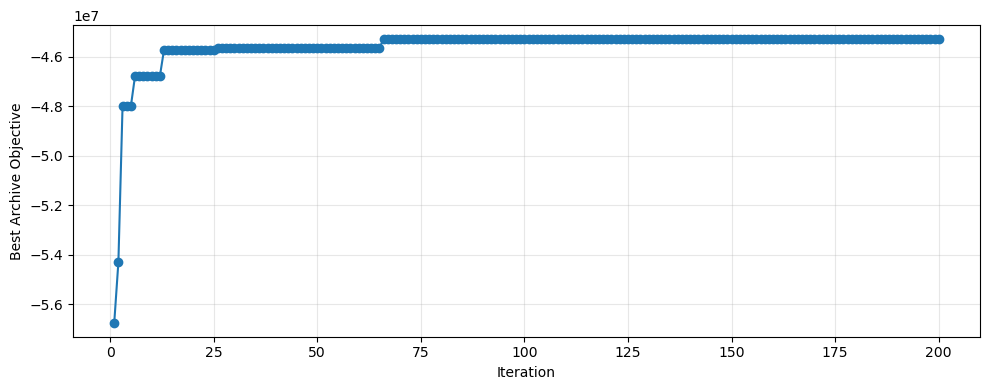

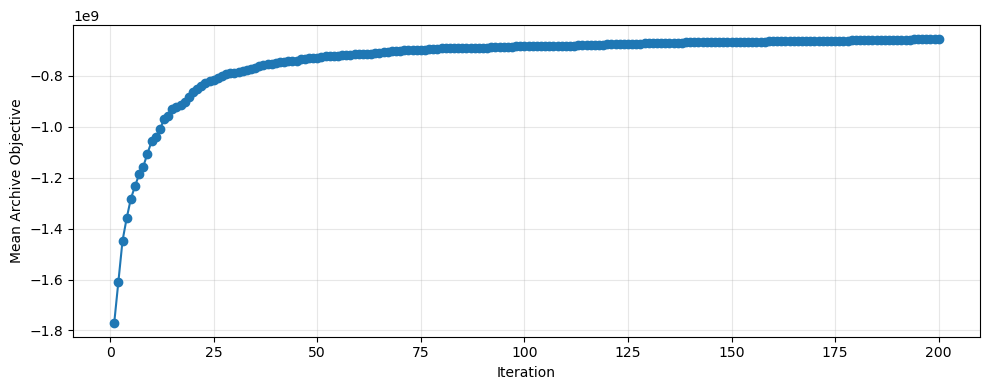

In [3]:
# Path to the saved iteration log
iteration_log_csv_path = f"{folder_path}\\{experiment_name}_iteration_log.csv"

log_df = pd.read_csv(iteration_log_csv_path)

# Plot convergence behaviour
fig, ax = plt.subplots(figsize=(10, 4), sharex=True)

# Best objective in archive
ax.plot(log_df["iteration"], log_df["best_objective_archive"], marker="o")
ax.set_xlabel("Iteration")
ax.set_ylabel("Best Archive Objective")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{img_folder}\\best_archive_periteration")
plt.show()

fig, ax = plt.subplots(figsize=(10, 4), sharex=True)

# Mean objective in archive
ax.plot(log_df["iteration"], log_df["mean_objective_archive"], marker="o")
ax.set_xlabel("Iteration")
ax.set_ylabel("Mean Archive Objective")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{img_folder}\\mean_archive_periteration")
plt.show()